Accuracy: 1.0


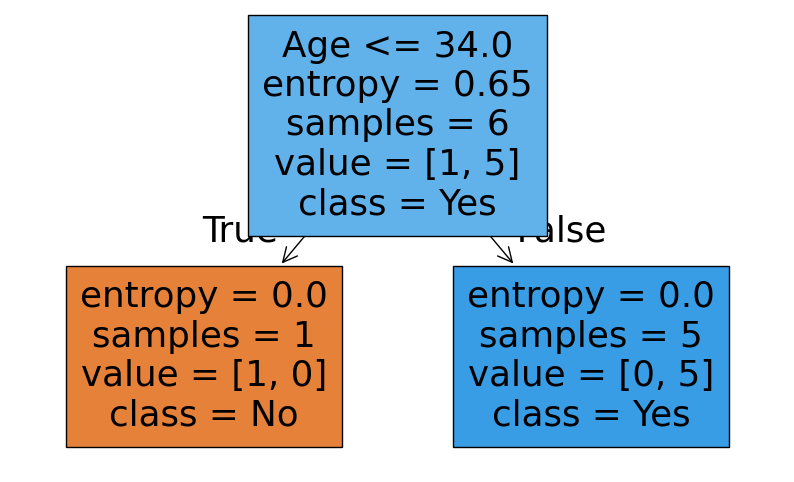

In [3]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn import tree


data = {
    'Age': [22, 25, 47, 52, 46, 56, 48, 55],
    'Salary': [15000, 29000, 48000, 60000, 52000, 61000, 59000, 65000],
    'Purchased': [0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

X = df[['Age', 'Salary']]
y = df['Purchased']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

model.fit(X_train, y_train)


predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


plt.figure(figsize=(10,6))

tree.plot_tree(
    model,
    feature_names=['Age', 'Salary'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

### ANOTHER IMPLEMENTATION


In [4]:
import pandas as pd,numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import GridSearchCV





In [5]:
data=load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [6]:
df=pd.DataFrame(data.data)
df['Target']=pd.DataFrame(data.target)
df.head()

,0,1,2,3,4,5,6,7,8,9,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
X=df.iloc[:,0:10]
y=df.iloc[:,10]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
RT=DecisionTreeRegressor(criterion='squared_error',max_depth=4)
RT.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=4)

In [9]:
y_pred=RT.predict(X_test)
print('r2_score ==> ',r2_score(y_test,y_pred))


r2_score ==>  0.3263754171777956


In [10]:
param_grid = {
    'max_depth':[2,3,4,5,6,8,10],
    'criterion':['squared_error','absolute_error'],
    'max_features':[0.3,0.5,0.7,1.0],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,5,10]
}

In [11]:
reg = GridSearchCV(DecisionTreeRegressor(),param_grid=param_grid)
reg.fit(X_train,y_train)
    

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [2, 3, 4, 5, 6, 8, 10],
                         'max_features': [0.3, 0.5, 0.7, 1.0],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]})

In [12]:
reg.best_score_

0.3569255081671174

In [13]:
reg.best_params_

{'criterion': 'squared_error',
 'max_depth': 3,
 'max_features': 0.3,
 'min_samples_leaf': 10,
 'min_samples_split': 10}

In [14]:
#Feature Importance

for importance, name in sorted(zip(RT.feature_importances_, X_train.columns),reverse=True):
  print (name, importance)

2 0.6292376415602774
8 0.21297760234671798
9 0.0662301595873956
7 0.02505676366418562
6 0.01920795115508609
5 0.01893381387571318
0 0.016807178071326048
4 0.011548889739298174
3 0.0
1 0.0


### Dtree visualization

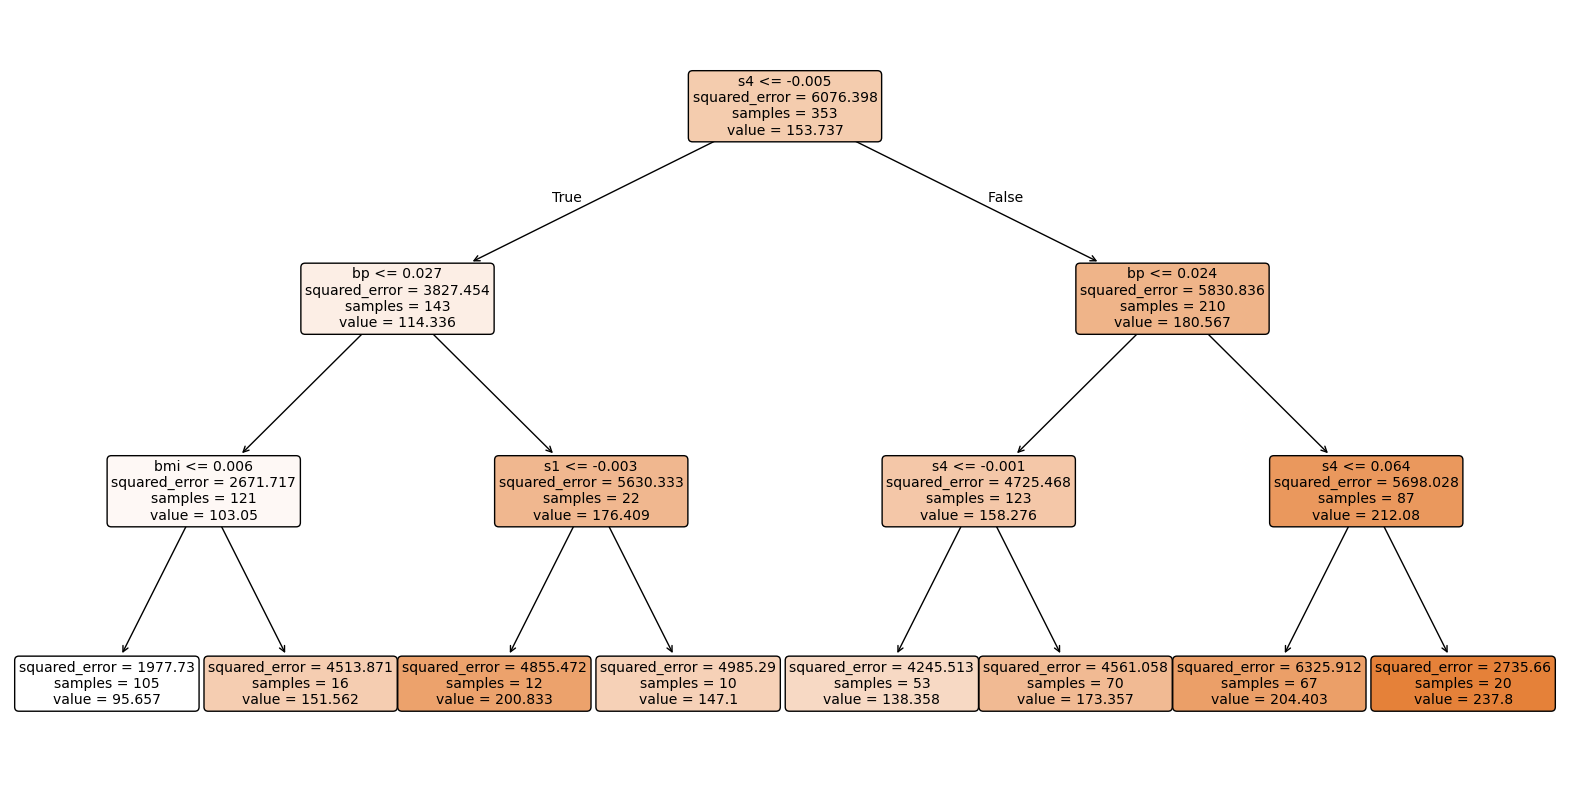

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Best trained model from GridSearchCV
best_tree = reg.best_estimator_

# Plot tree
plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    feature_names=data.feature_names,
    filled=True,
    rounded=True
)

plt.show()